Solving model...


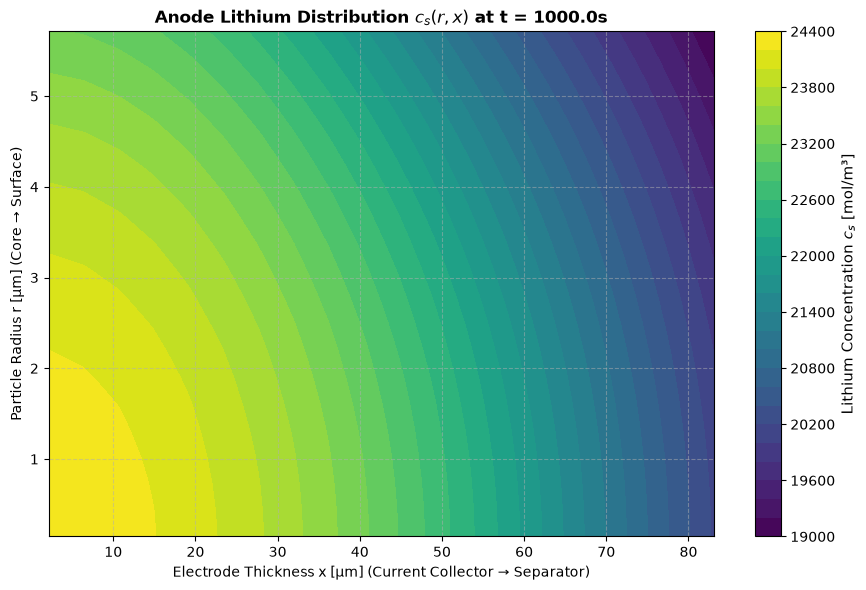

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pybamm

# 1. Setup and solve full DFN model
print("Solving model...")
model = pybamm.lithium_ion.DFN()
params = pybamm.ParameterValues("Chen2020")
sim = pybamm.Simulation(model, parameter_values=params)
sol = sim.solve([0, 1800])  # Discharge for 30 minutes

# 2. Extract full 2D spatial grid (x and r)
proc_cs_n = sol["Negative particle concentration [mol.m-3]"]

# Get exact mesh node arrays
x_n = sim.mesh["negative electrode"].nodes  # Electrode thickness coordinates
r_n = proc_cs_n.mesh.nodes  # Particle radius coordinates

# 3. Evaluate concentration matrix at a specific time (e.g., t = 1000s)
t_target = 1000.0

# Evaluates concentration across all r and x nodes -> Shape: (len(r), len(x))
cs_2d = proc_cs_n(t=t_target, r=r_n, x=x_n)

# 4. Create Heatmap / Contour Plot
plt.figure(figsize=(9, 6))
# Create meshgrid for plotting
X, R = np.meshgrid(x_n * 1e6, r_n * 1e6)  # Convert meters to micrometers (µm)

contour = plt.contourf(X, R, cs_2d, levels=30, cmap="viridis")
cbar = plt.colorbar(contour)
cbar.set_label("Lithium Concentration $c_s$ [mol/m³]", fontsize=11)

plt.title(
    f"Anode Lithium Distribution $c_s(r, x)$ at t = {t_target}s",
    fontsize=12,
    fontweight="bold",
)
plt.xlabel("Electrode Thickness x [µm] (Current Collector → Separator)")
plt.ylabel("Particle Radius r [µm] (Core → Surface)")
plt.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

Solving fast-charge simulation...
CC step start time: 60.0 s
CC step end time: 106.8 s
Evaluating concentration heatmap at mid-CC: t = 83.4 s


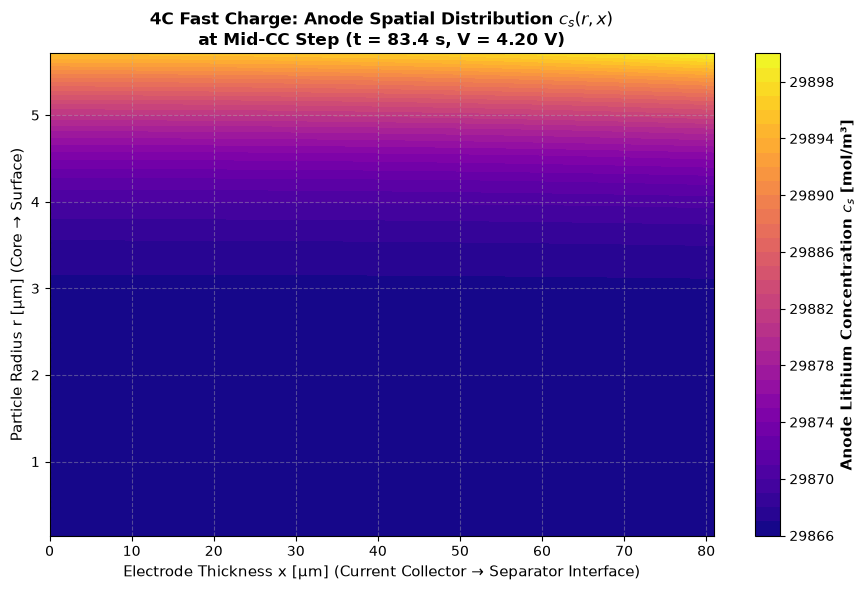

In [5]:
import matplotlib.pyplot as plt
import numpy as np
import pybamm

# ==========================================
# 1. SETUP MODEL & PARAMETERS
# ==========================================
print("Solving fast-charge simulation...")
model = pybamm.lithium_ion.DFN()  # Full continuum DFN model
params = pybamm.ParameterValues("Chen2020")

# Set Initial SoC to 5% so initial resting voltage sits inside valid bounds
params["Initial SoC"] = 0.05

# Define CCCV fast-charge experiment protocol
experiment = pybamm.Experiment(
    [
        (
            "Rest for 1 minute",
            "Charge at 4C until 4.2 V",  # Fast Constant Current (CC) step
            "Hold at 4.2 V until C/20",  # Constant Voltage (CV) step
        )
    ]
)

sim = pybamm.Simulation(model, parameter_values=params, experiment=experiment)
sol = sim.solve()

# ==========================================
# 2. LOCATE MIDDLE OF CC CHARGE STEP
# ==========================================
# Extract global solution arrays
time = sol["Time [s]"].entries
current = sol["Current [A]"].entries

# Find non-zero charge current region (charging current is negative in PyBaMM)
charge_indices = np.where(current < -0.1)[0]

t_cc_start = time[charge_indices[0]]
t_cc_end = time[charge_indices[-1]]
t_mid_cc = (t_cc_start + t_cc_end) / 2.0

print(f"CC step start time: {t_cc_start:.1f} s")
print(f"CC step end time: {t_cc_end:.1f} s")
print(f"Evaluating concentration heatmap at mid-CC: t = {t_mid_cc:.1f} s")

# ==========================================
# 3. EXTRACT 2D SPATIAL DATA (x & r)
# ==========================================
proc_cs_n = sol["Negative particle concentration [mol.m-3]"]

# Extract node grids directly from simulation mesh
x_n = sim.mesh["negative electrode"].nodes  # Anode thickness [m]
r_n = proc_cs_n.mesh.nodes  # Particle radius [m]

# Evaluate 2D concentration matrix c_s(r, x) at t = t_mid_cc
cs_2d = proc_cs_n(t=t_mid_cc, r=r_n, x=x_n)

# Convert meter coordinates to micrometers (µm) for plotting
x_n_um = (x_n - x_n[0]) * 1e6  # Relative distance from Current Collector
r_n_um = r_n * 1e6

# ==========================================
# 4. PLOT 2D SPATIAL HEATMAP
# ==========================================
plt.figure(figsize=(9, 6))
X, R = np.meshgrid(x_n_um, r_n_um)

contour = plt.contourf(X, R, cs_2d, levels=35, cmap="plasma")
cbar = plt.colorbar(contour)
cbar.set_label(
    "Anode Lithium Concentration $c_s$ [mol/m³]", fontsize=11, fontweight="bold"
)

plt.title(
    f"4C Fast Charge: Anode Spatial Distribution $c_s(r, x)$\n"
    f"at Mid-CC Step (t = {t_mid_cc:.1f} s, V = {sol['Terminal voltage [V]'](t_mid_cc):.2f} V)",
    fontsize=12,
    fontweight="bold",
)
plt.xlabel(
    "Electrode Thickness x [µm] (Current Collector → Separator Interface)",
    fontsize=11,
)
plt.ylabel("Particle Radius r [µm] (Core → Surface)", fontsize=11)
plt.grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()